# VMGP: Variational Auto-Encoder based Multi-task Genomic Prediction
## Adattamento per Dataset Adaptmap (Classificazione Razze Ovine)

Questo notebook implementa l'architettura **VMGP** descritta nel paper *"VMGP: A unified variational auto-encoder based multi-task model..."*[cite: 10].

### Adattamenti per Adaptmap:
1. **Task:** Classificazione Multi-classe (Razza) invece di Regressione Fenotipica.
2. **Input:** File binari PLINK (`.bed`, `.bim`, `.fam`).
3. **Framework:** PyTorch Lightning per una gestione modulare del training.

---

In [1]:
# Installazione delle dipendenze necessarie (decommentare se necessario)
# !pip install torch torchvision torchaudio pytorch-lightning pandas-plink scikit-learn matplotlib

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pandas_plink import read_plink1_bin
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Se disponibile, usa torchmetrics per calcolare l'accuratezza in modo efficiente
try:
    import torchmetrics
except ImportError:
    print("Warning: torchmetrics non installato. Le metriche saranno calcolate manualmente.")
    torchmetrics = None

# Imposta seed per riproducibilità
pl.seed_everything(42)

KeyboardInterrupt: 

## 1. Definizione dell'Architettura VMGP

Implementazione fedele ai moduli descritti nel paper:
- **Encoder**: Compressione dati genomici[cite: 120].
- **Sampler**: VAE Reparameterization trick[cite: 176].
- **Decoder**: Ricostruzione genomica (Auxiliary Task)[cite: 188].
- **Predictor**: Predizione Fenotipo/Razza (Primary Task)[cite: 190].

In [ ]:
class VMGP_Network(nn.Module):
    def __init__(self, num_snps, num_classes, d1=2048, d2=512, d3=128, latent_dim=128):
        super().__init__()
        
        # --- Encoder [cite: 174] ---
        # Input -> Linear -> BatchNorm -> LeakyReLU -> Dropout
        self.encoder = nn.Sequential(
            nn.Linear(num_snps, d1),
            nn.BatchNorm1d(d1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(d1, d2),
            nn.BatchNorm1d(d2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1)
        )
        
        # --- Sampler (VAE) [cite: 176] ---
        # Genera vettori media (mu) e log-varianza (sigma)
        self.fc_mu = nn.Linear(d2, latent_dim)
        self.fc_logvar = nn.Linear(d2, latent_dim)
        
        # --- Decoder (Genomic Reconstruction) [cite: 188] ---
        # Speculare all'encoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, d2),
            nn.BatchNorm1d(d2),
            nn.LeakyReLU(0.2),
            nn.Linear(d2, d1),
            nn.BatchNorm1d(d1),
            nn.LeakyReLU(0.2),
            nn.Linear(d1, num_snps) # Output dimensione originale SNP
        )
        
        # --- Predictor (Breed Classification) [cite: 191] ---
        # Latent -> d3 -> Output
        self.predictor = nn.Sequential(
            nn.Linear(latent_dim, d3),
            nn.BatchNorm1d(d3),
            nn.LeakyReLU(0.2),
            nn.Linear(d3, num_classes) # Output logits per le classi di razza
        )

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = mu + sigma * epsilon
        Permette la backpropagation attraverso il campionamento stocastico[cite: 179].
        """
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def forward(self, x):
        # 1. Encoding
        encoded = self.encoder(x)
        
        # 2. Sampling Latente
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        
        # 3. Multi-Task Outputs
        x_recon = self.decoder(z)
        y_logits = self.predictor(z)
        
        return x_recon, y_logits, mu, logvar

## 2. Lightning Module (Logica di Training)

Gestisce la Loss Function combinata:
$$ \mathcal{L} = \alpha \times \mathcal{L}_{rec} + (1-\alpha) \times \mathcal{L}_{pre} $$
Dove:
- $\mathcal{L}_{rec}$: MSE + KL Divergence [cite: 211]
- $\mathcal{L}_{pre}$: Cross Entropy (adattata per classificazione) [cite: 219]

In [ ]:
class VMGP_LightningSystem(pl.LightningModule):
    def __init__(self, num_snps, num_classes, alpha=0.5, lr=0.0001):
        super().__init__()
        self.save_hyperparameters()
        self.model = VMGP_Network(num_snps, num_classes)
        self.alpha = alpha

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        # Learning rate 0.0001 come da paper [cite: 224]
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

    def _common_step(self, batch, batch_idx, stage):
        x, y = batch
        x_recon, y_logits, mu, logvar = self(x)
        
        # --- Loss Ricostruzione (MSE + KL) ---
        mse_loss = F.mse_loss(x_recon, x, reduction='mean')
        # KL Divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        kl_loss /= x.size(0) # Normalizzazione per batch
        
        # Combinazione reconstruction loss (il peso 0.0001 per KL è standard nei VAE)
        loss_rec = mse_loss + 0.0001 * kl_loss
        
        # --- Loss Predizione (CrossEntropy) ---
        loss_pre = F.cross_entropy(y_logits, y)
        
        # --- Total Loss [cite: 203] ---
        total_loss = self.alpha * loss_rec + (1 - self.alpha) * loss_pre
        
        # Calcolo accuratezza
        preds = torch.argmax(y_logits, dim=1)
        acc = (preds == y).float().mean()
        
        # Logging
        self.log(f'{stage}_loss', total_loss, prog_bar=True)
        self.log(f'{stage}_acc', acc, prog_bar=True)
        self.log(f'{stage}_rec_loss', loss_rec, prog_bar=False)
        
        return total_loss

    def training_step(self, batch, batch_idx):
        return self._common_step(batch, batch_idx, 'train')

    def validation_step(self, batch, batch_idx):
        return self._common_step(batch, batch_idx, 'val')
    
    def test_step(self, batch, batch_idx):
        return self._common_step(batch, batch_idx, 'test')

## 3. Data Module: PLINK Loading e Quality Control

Carica i file `.bed`, `.bim`, `.fam` ed esegue il preprocessing standard per genomica:
1.  Rimozione SNP con troppi missing values (GENO).
2.  Rimozione SNP con Minor Allele Frequency bassa (MAF).
3.  Imputazione valori mancanti.

In [ ]:
class GenomicDataModule(pl.LightningDataModule):
    def __init__(self, bed_path, batch_size=32, 
                 maf_thresh=0.05, geno_thresh=0.1, min_samples_per_class=10,
                 # --- NUOVI PARAMETRI PRUNING ---
                 ld_pruning=True, ld_threshold=0.2, ld_window=50):
        super().__init__()
        self.bed_path = bed_path
        self.batch_size = batch_size
        self.maf_thresh = maf_thresh
        self.geno_thresh = geno_thresh
        self.min_samples = min_samples_per_class 
        
        # Parametri LD Pruning
        self.ld_pruning = ld_pruning
        self.ld_threshold = ld_threshold
        self.ld_window = ld_window
        
        self.imputer = SimpleImputer(strategy='mean')
        self.le = LabelEncoder()
        
    def setup(self, stage=None):
        if hasattr(self, 'train_dataset'):
            return

        print(f"--- Caricamento Dataset PLINK: {self.bed_path} ---")
        if not os.path.exists(self.bed_path):
            print(f"ERRORE: Il file {self.bed_path} non esiste.")
            return # Aggiunto return per sicurezza

        try:
            G = read_plink1_bin(self.bed_path, verbose=False)
            fam = G.sample.to_dataframe()
            y_raw = fam['fid'].values 
            
            # Gestione orientamento matrice
            X = G.values 
            if X.shape[1] == len(y_raw):
                print("Trasposizione matrice in corso (da SNPxSample a SamplexSNP)...")
                X = X.T
            
            print(f"Shape iniziale: {X.shape}")

            # --- FILTRO CLASSI RARE ---
            unique_classes, counts = np.unique(y_raw, return_counts=True)
            valid_classes = unique_classes[counts >= self.min_samples]
            mask = np.isin(y_raw, valid_classes)
            
            n_removed = len(y_raw) - mask.sum()
            print(f"Filtro Razze: Rimuovo {n_removed} campioni appartenenti a razze con < {self.min_samples} esemplari.")
            
            X = X[mask]
            y_raw = y_raw[mask]

            # --- QC Standard ---
            # 1. Missingness
            print("QC: Filtro Missingness SNP...")
            missing_rate_snps = np.isnan(X).mean(axis=0)
            X = X[:, missing_rate_snps < self.geno_thresh]
            
            # 2. Imputazione
            print("QC: Imputazione valori mancanti...")
            X = self.imputer.fit_transform(X)
            
            # 3. MAF
            print("QC: Filtro MAF...")
            af = np.mean(X, axis=0) / 2.0
            maf = np.minimum(af, 1 - af)
            X = X[:, maf > self.maf_thresh]
            
            # --- 4. LD PRUNING (NUOVO) ---
            if self.ld_pruning:
                X = self._prune_ld(X)

            print(f"Dimensioni finali per training: {X.shape}")

            # Encoding
            y = self.le.fit_transform(y_raw)
            self.num_classes = len(self.le.classes_)
            self.num_snps = X.shape[1]
            print(f"Numero Razze Valide: {self.num_classes}")
            
            # --- SPLIT SICURO ---
            try:
                X_train, X_temp, y_train, y_temp = train_test_split(
                    X, y, test_size=0.3, stratify=y, random_state=42
                )
                
                X_val, X_test, y_val, y_test = train_test_split(
                    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
                )
            except ValueError as e:
                print("\nERRORE CRITICO NELLO SPLIT:")
                print(f"{e}")
                print("SUGGERIMENTO: Alcune razze hanno troppi pochi campioni per essere divise. Alza 'min_samples_per_class'.")
                

            # Creazione Dataset
            self.train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
            self.val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
            self.test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
            
        except Exception as e:
            print(f"Errore generico nel setup: {e}")
            

    def _prune_ld(self, X):
        """
        Rimuove SNP in Linkage Disequilibrium (LD) alto usando PyTorch per velocità.
        """
        print(f"\n✂️ LD Pruning (Window={self.ld_window}, Thresh={self.ld_threshold})...")
        n_samples, n_snps = X.shape
        
        # Usa GPU se disponibile per calcolare la correlazione velocemente
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"   Running on: {device}")
        
        # Standardizzazione temporanea per il calcolo della correlazione di Pearson
        # (X - mean) / std
        X_std_calc = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)
        X_tensor = torch.tensor(X_std_calc, device=device, dtype=torch.float32)
        
        to_remove = np.zeros(n_snps, dtype=bool)
        window_size = self.ld_window
        step_size = 5 # Salto per velocizzare
        
        try:
            i = 0
            while i < n_snps:
                if to_remove[i]:
                    i += 1
                    continue
                
                # Definisci finestra
                start = i + 1
                end = min(i + 1 + window_size, n_snps)
                
                if start >= end:
                    i += step_size
                    continue
                
                # Prendi solo gli indici non ancora rimossi nella finestra
                window_indices = [j for j in range(start, end) if not to_remove[j]]
                
                if not window_indices:
                    i += step_size
                    continue
                
                # Calcolo Correlazione (R^2)
                # Pearson Correlation = dot product di vettori standardizzati diviso N
                pivot = X_tensor[:, i].unsqueeze(1) # SNP corrente (N, 1)
                targets = X_tensor[:, window_indices] # SNP vicini (N, Window)
                
                corrs = torch.mm(pivot.t(), targets).squeeze(0) / n_samples
                r2 = corrs ** 2
                
                # Trova SNP che superano la soglia
                bad_rel_idx = torch.nonzero(r2 > self.ld_threshold).squeeze(-1).cpu().numpy()
                
                # Marca come da rimuovere
                # Nota: bad_rel_idx sono indici relativi a window_indices
                if bad_rel_idx.ndim == 0 and bad_rel_idx.size == 1:
                    bad_rel_idx = [bad_rel_idx] # Gestione caso singolo
                    
                for local_idx in bad_rel_idx:
                    global_idx = window_indices[local_idx]
                    to_remove[global_idx] = True
                    
                i += step_size
                
                if i % 5000 == 0:
                    print(f"   ...scansionati {i}/{n_snps} SNP")

        except RuntimeError as e:
            print(f"⚠️ Errore memoria GPU durante LD Pruning: {e}. Skipping.")
            return X

        mask_keep = ~to_remove
        n_removed = np.sum(to_remove)
        print(f"✅ LD Pruning completato. Rimossi {n_removed} SNP ridondanti.")
        
        return X[:, mask_keep]

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=0)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, num_workers=0)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, num_workers=0)

In [ ]:
# --- MAIN EXECUTION ---

# 1. Configurazione
# Inserisci qui il percorso al tuo file .bed (senza estensione se vuoi, ma pandas_plink spesso preferisce il path completo)
BED_FILE_PATH = "./data/ADAPTmap_genotypeTOP_20160222_full.bed"  # <-- MODIFICA QUESTO PATH

# Verifica esistenza file fittizia per evitare errori se esegui il notebook senza dati
if not os.path.exists(BED_FILE_PATH):
    print(f"ATTENZIONE: Il file {BED_FILE_PATH} non esiste. Creazione dati dummy per test.")
    # (Codice opzionale per creare dummy bed non incluso per brevità, assicurati di avere i dati)

# 2. Inizializzazione Data Module
dm = GenomicDataModule(bed_path=BED_FILE_PATH, batch_size=32)
# Eseguiamo setup manuale per leggere le dimensioni prima di creare il modello
try:
    dm.setup()
    print(f"Classi Razza Identificate: {dm.num_classes}")
    
    # 3. Inizializzazione Modello
    model = VMGP_LightningSystem(
        num_snps=dm.num_snps,
        num_classes=dm.num_classes,
        alpha=0.5, # Bilanciamento loss [cite: 205]
        lr=0.0001
    )

    # 4. Trainer
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc', mode='max', filename='vmgp-best-checkpoint'
    )
    
    # Parametri di training standard del paper: 200 epoche [cite: 224]
    trainer = pl.Trainer(
        max_epochs=100,
        accelerator="auto", # Usa GPU se disponibile
        devices=1,
        callbacks=[checkpoint_callback],
        log_every_n_steps=10
    )

    # 5. Avvio Training
    trainer.fit(model, dm)

    # 6. Test Finale
    print("Avvio test sul dataset di test...")
    trainer.test(model, dm)

except Exception as e:
    print(f"\nImpossibile avviare il training: {e}")
    print("Assicurati di aver impostato il percorso corretto ai file PLINK.")

--- Caricamento Dataset PLINK: ./data/ADAPTmap_genotypeTOP_20160222_full.bed ---
Shape iniziale: (4653, 53347)
Filtro Razze: Rimuovo 128 campioni appartenenti a razze con < 10 esemplari.
QC: Filtro Missingness SNP...
QC: Imputazione valori mancanti...
QC: Filtro MAF...

✂️ LD Pruning (Window=50, Thresh=0.2)...
   Running on: cuda
   ...scansionati 10000/51231 SNP
   ...scansionati 30000/51231 SNP
   ...scansionati 40000/51231 SNP
✅ LD Pruning completato. Rimossi 1491 SNP ridondanti.
Dimensioni finali per training: (4525, 49740)
Numero Razze Valide: 114
Classi Razza Identificate: 114


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type         | Params | Mode 
-----------------------------------------------
0 | model | VMGP_Network | 206 M  | train
-----------------------------------------------
206 M     Trainable params
0         Non-trainable params
206 M     Total params
824.503   Total estimated model params size (MB)
25        Modules in train mode
0         Modules in eval mode


Epoch 99: 100%|██████████| 99/99 [00:03<00:00, 31.51it/s, v_num=36, train_loss=0.172, train_acc=1.000, val_loss=0.356, val_acc=0.940]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 99/99 [00:03<00:00, 31.49it/s, v_num=36, train_loss=0.172, train_acc=1.000, val_loss=0.356, val_acc=0.940]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Avvio test sul dataset di test...
Testing DataLoader 0: 100%|██████████| 22/22 [00:00<00:00, 277.95it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.938144326210022
        test_loss           0.3485141396522522
      test_rec_loss         0.3863559663295746
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## 4. Valutazione Dettagliata del Modello

Metriche complete per la classificazione multi-classe:
- **Accuracy, Precision, Recall, F1-Score** (micro, macro, weighted)
- **Confusion Matrix** con visualizzazione heatmap
- **Classification Report** per classe
- **Top-K Accuracy** per valutare predizioni alternative
- **Analisi dello Spazio Latente** con t-SNE/UMAP

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, top_k_accuracy_score
)
import seaborn as sns
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

def evaluate_multiclass_model(model, datamodule, stage='test'):
    """
    Valutazione completa per classificazione multi-classe
    
    Args:
        model: Modello PyTorch Lightning
        datamodule: DataModule con i dati
        stage: 'test', 'val', o 'train'
    """
    
    # Seleziona il dataloader appropriato
    if stage == 'test':
        loader = datamodule.test_dataloader()
    elif stage == 'val':
        loader = datamodule.val_dataloader()
    else:
        loader = datamodule.train_dataloader()
    
    # Modalità evaluation
    model.eval()
    model.freeze()
    
    # Colleziona predizioni e labels
    all_preds = []
    all_labels = []
    all_probs = []
    all_latents = []
    
    print(f"\n{'='*70}")
    print(f"📊 VALUTAZIONE MODELLO - {stage.upper()} SET")
    print(f"{'='*70}\n")
    
    with torch.no_grad():
        for batch in loader:
            x, y = batch
            
            # Forward pass
            x_recon, y_logits, mu, logvar = model(x)
            
            # Probabilità e predizioni
            probs = F.softmax(y_logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
            all_probs.append(probs.cpu())
            all_latents.append(mu.cpu())
    
    # Concatena tutti i batch
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_probs = torch.cat(all_probs).numpy()
    latents = torch.cat(all_latents).numpy()
    
    # ============================================================================
    # 1. METRICHE GLOBALI
    # ============================================================================
    print("1️⃣  METRICHE GLOBALI\n")
    
    acc = accuracy_score(y_true, y_pred)
    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    
    recall_micro = recall_score(y_true, y_pred, average='micro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"   Accuracy:                {acc*100:6.2f}%")
    print(f"\n   Precision (Micro):       {precision_micro*100:6.2f}%")
    print(f"   Precision (Macro):       {precision_macro*100:6.2f}%")
    print(f"   Precision (Weighted):    {precision_weighted*100:6.2f}%")
    print(f"\n   Recall (Micro):          {recall_micro*100:6.2f}%")
    print(f"   Recall (Macro):          {recall_macro*100:6.2f}%")
    print(f"   Recall (Weighted):       {recall_weighted*100:6.2f}%")
    print(f"\n   F1-Score (Micro):        {f1_micro*100:6.2f}%")
    print(f"   F1-Score (Macro):        {f1_macro*100:6.2f}%")
    print(f"   F1-Score (Weighted):     {f1_weighted*100:6.2f}%")
    
    # ============================================================================
    # 2. TOP-K ACCURACY
    # ============================================================================
    print(f"\n\n2️⃣  TOP-K ACCURACY\n")
    
    for k in [1, 3, 5, 10]:
        if k <= datamodule.num_classes:
            top_k_acc = top_k_accuracy_score(y_true, y_probs, k=k)
            print(f"   Top-{k:2d} Accuracy:         {top_k_acc*100:6.2f}%")
    
    # ============================================================================
    # 3. CLASSIFICATION REPORT PER CLASSE
    # ============================================================================
    print(f"\n\n3️⃣  CLASSIFICATION REPORT (Prime 20 Classi)\n")
    
    target_names = datamodule.le.classes_
    report = classification_report(
        y_true, y_pred, 
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )
    
    # Mostra solo le prime 20 classi per non sovraccaricare
    df_report = pd.DataFrame(report).transpose()
    print(df_report.head(20).to_string())
    
    # ============================================================================
    # 4. CONFUSION MATRIX
    # ============================================================================
    print(f"\n\n4️⃣  CONFUSION MATRIX (Visualizzazione)\n")
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Per dataset con molte classi, mostra solo le top N più popolate
    if datamodule.num_classes > 20:
        print("   ⚠️  Troppe classi per visualizzare la matrice completa.")
        print(f"   Mostro le top 15 classi più popolate...\n")
        
        # Trova le classi più popolate
        unique, counts = np.unique(y_true, return_counts=True)
        top_classes_idx = np.argsort(counts)[-15:][::-1]
        
        # Filtra confusion matrix
        mask = np.isin(y_true, top_classes_idx)
        y_true_filtered = y_true[mask]
        y_pred_filtered = y_pred[mask]
        
        cm_filtered = confusion_matrix(y_true_filtered, y_pred_filtered, labels=top_classes_idx)
        labels_filtered = target_names[top_classes_idx]
        
        plt.figure(figsize=(14, 12))
        sns.heatmap(
            cm_filtered, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels_filtered,
            yticklabels=labels_filtered,
            cbar_kws={'label': 'Count'}
        )
        plt.title(f'Confusion Matrix - Top 15 Razze ({stage.upper()} Set)', fontsize=14, weight='bold')
        plt.ylabel('Vero', fontsize=12)
        plt.xlabel('Predetto', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(16, 14))
        sns.heatmap(
            cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Count'}
        )
        plt.title(f'Confusion Matrix Completa ({stage.upper()} Set)', fontsize=14, weight='bold')
        plt.ylabel('Vero', fontsize=12)
        plt.xlabel('Predetto', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    
    # ============================================================================
    # 5. ANALISI SPAZIO LATENTE (t-SNE)
    # ============================================================================
    print(f"\n\n5️⃣  SPAZIO LATENTE (t-SNE Visualization)\n")
    
    # Campiona per velocità se troppi dati
    if len(latents) > 5000:
        print("   Campionamento di 5000 punti per visualizzazione...")
        idx_sample = np.random.choice(len(latents), 5000, replace=False)
        latents_sample = latents[idx_sample]
        labels_sample = y_true[idx_sample]
    else:
        latents_sample = latents
        labels_sample = y_true
    
    print("   Calcolo t-SNE (può richiedere alcuni minuti)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    latents_2d = tsne.fit_transform(latents_sample)
    
    # Plot
    plt.figure(figsize=(14, 10))
    
    # Se troppe classi, usa colori discreti solo per le top N
    if datamodule.num_classes > 20:
        # Colora solo le top 10 classi, resto in grigio
        unique, counts = np.unique(labels_sample, return_counts=True)
        top_10 = np.argsort(counts)[-10:][::-1]
        
        colors = np.where(np.isin(labels_sample, top_10), labels_sample, -1)
        scatter = plt.scatter(
            latents_2d[:, 0], 
            latents_2d[:, 1], 
            c=colors,
            cmap='tab20',
            alpha=0.6,
            s=10
        )
        plt.title(f't-SNE dello Spazio Latente (Top 10 Razze Colorate)', fontsize=14, weight='bold')
    else:
        scatter = plt.scatter(
            latents_2d[:, 0], 
            latents_2d[:, 1], 
            c=labels_sample,
            cmap='tab20',
            alpha=0.6,
            s=20
        )
        plt.colorbar(scatter, label='Classe Razza')
        plt.title(f't-SNE dello Spazio Latente', fontsize=14, weight='bold')
    
    plt.xlabel('t-SNE Dim 1')
    plt.ylabel('t-SNE Dim 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*70}")
    print("✅ VALUTAZIONE COMPLETATA")
    print(f"{'='*70}\n")
    
    return {
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        'classification_report': report,
        'latents': latents,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_probs': y_probs
    }

⚠️  Nessun checkpoint trovato, uso modello corrente

📊 VALUTAZIONE MODELLO - TEST SET

1️⃣  METRICHE GLOBALI

   Accuracy:                 93.81%

   Precision (Micro):        93.81%
   Precision (Macro):        91.22%
   Precision (Weighted):     93.35%

   Recall (Micro):           93.81%
   Recall (Macro):           89.91%
   Recall (Weighted):        93.81%

   F1-Score (Micro):         93.81%
   F1-Score (Macro):         89.88%
   F1-Score (Weighted):      93.15%


2️⃣  TOP-K ACCURACY

   Top- 1 Accuracy:          93.81%
   Top- 3 Accuracy:          97.64%
   Top- 5 Accuracy:          99.26%
   Top-10 Accuracy:          99.71%


3️⃣  CLASSIFICATION REPORT (Prime 20 Classi)

     precision    recall  f1-score  support
ABR   1.000000  1.000000  1.000000      8.0
ALP   1.000000  1.000000  1.000000     42.0
ANG   0.939394  1.000000  0.968750     62.0
ANK   1.000000  0.666667  0.800000      3.0
ARG   1.000000  1.000000  1.000000      3.0
ARR   1.000000  1.000000  1.000000      2.0
ASP 

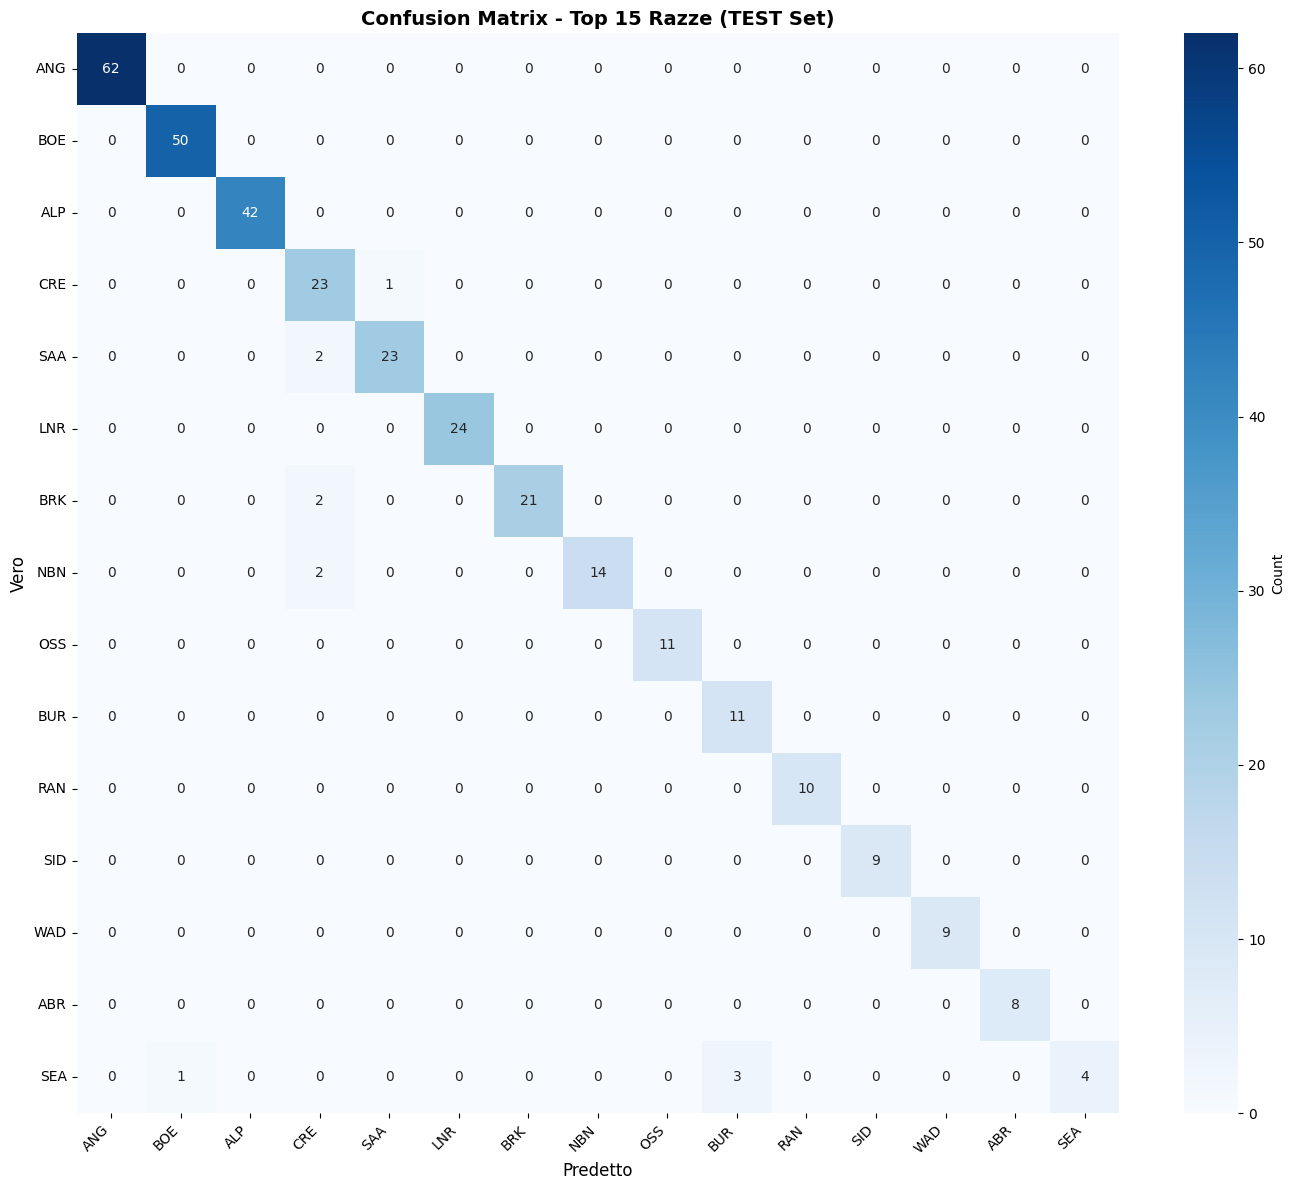



5️⃣  SPAZIO LATENTE (t-SNE Visualization)

   Calcolo t-SNE (può richiedere alcuni minuti)...


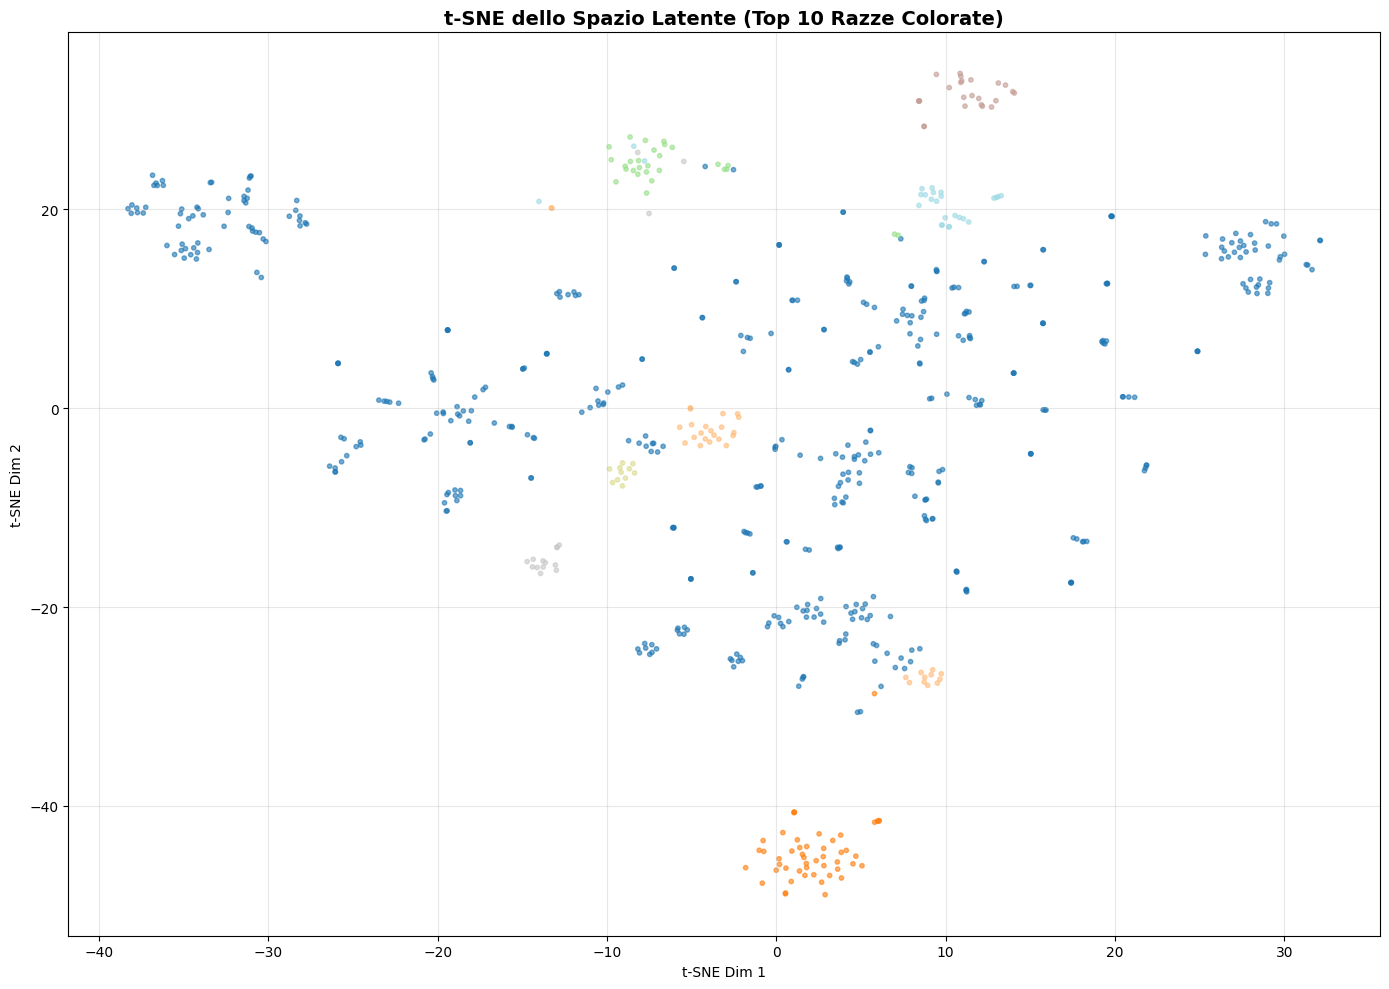


✅ VALUTAZIONE COMPLETATA



In [ ]:
# === ESEGUI VALUTAZIONE SUL TEST SET ===

# Carica il miglior checkpoint se esiste
checkpoint_path = "lightning_logs/version_0/checkpoints/vmgp-best-checkpoint.ckpt"

if os.path.exists(checkpoint_path):
    print(f"📥 Caricamento miglior checkpoint: {checkpoint_path}")
    model = VMGP_LightningSystem.load_from_checkpoint(
        checkpoint_path,
        num_snps=dm.num_snps,
        num_classes=dm.num_classes
    )
else:
    print("⚠️  Nessun checkpoint trovato, uso modello corrente")

# Esegui valutazione completa
results = evaluate_multiclass_model(model, dm, stage='test')

### Analisi Aggiuntive

Metriche opzionali per approfondire l'analisi:


📉 CLASSI CON PRESTAZIONI PIÙ BASSE (Bottom 10 per F1-Score)

  Razza  F1-Score  Support
    GOG  0.000000        2
    MOR  0.000000        2
SEAxGAL  0.000000        3
    CHA  0.000000        1
    KAR  0.000000        3
    NGD  0.000000        1
    GAL  0.400000        3
SAAxCRE  0.400000        3
    SEA  0.444444        8
    RSK  0.500000        3


📊 DISTRIBUZIONE CONFIDENZE DELLE PREDIZIONI

   Confidenza media (predizioni corrette):   0.9491
   Confidenza media (predizioni sbagliate):  0.5730


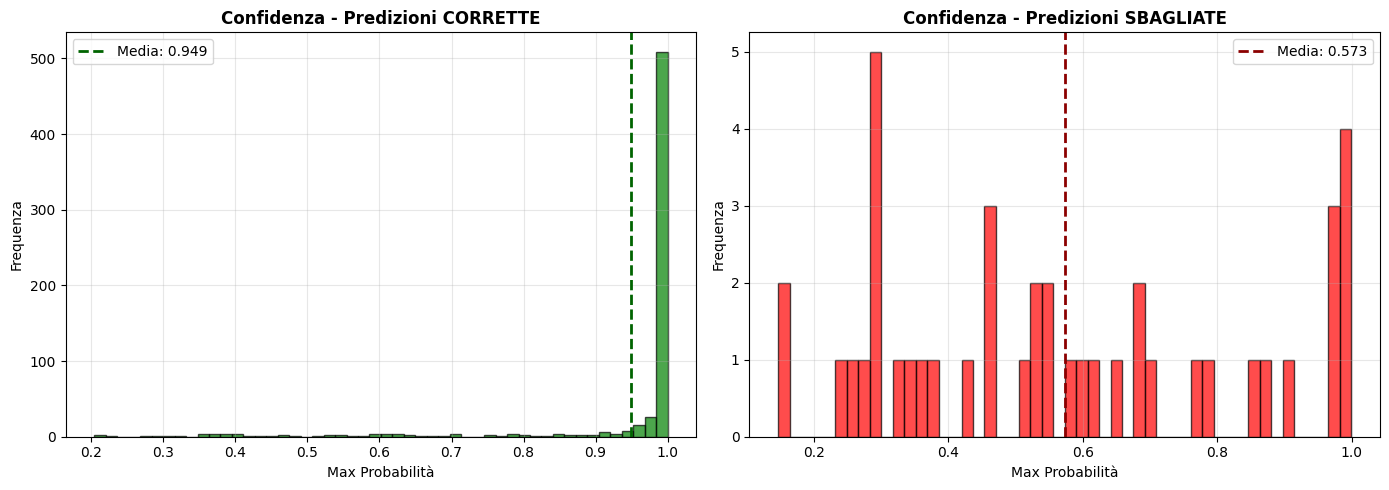



🔥 CONFUSION MATRIX NORMALIZZATA (per riga - recall per classe)



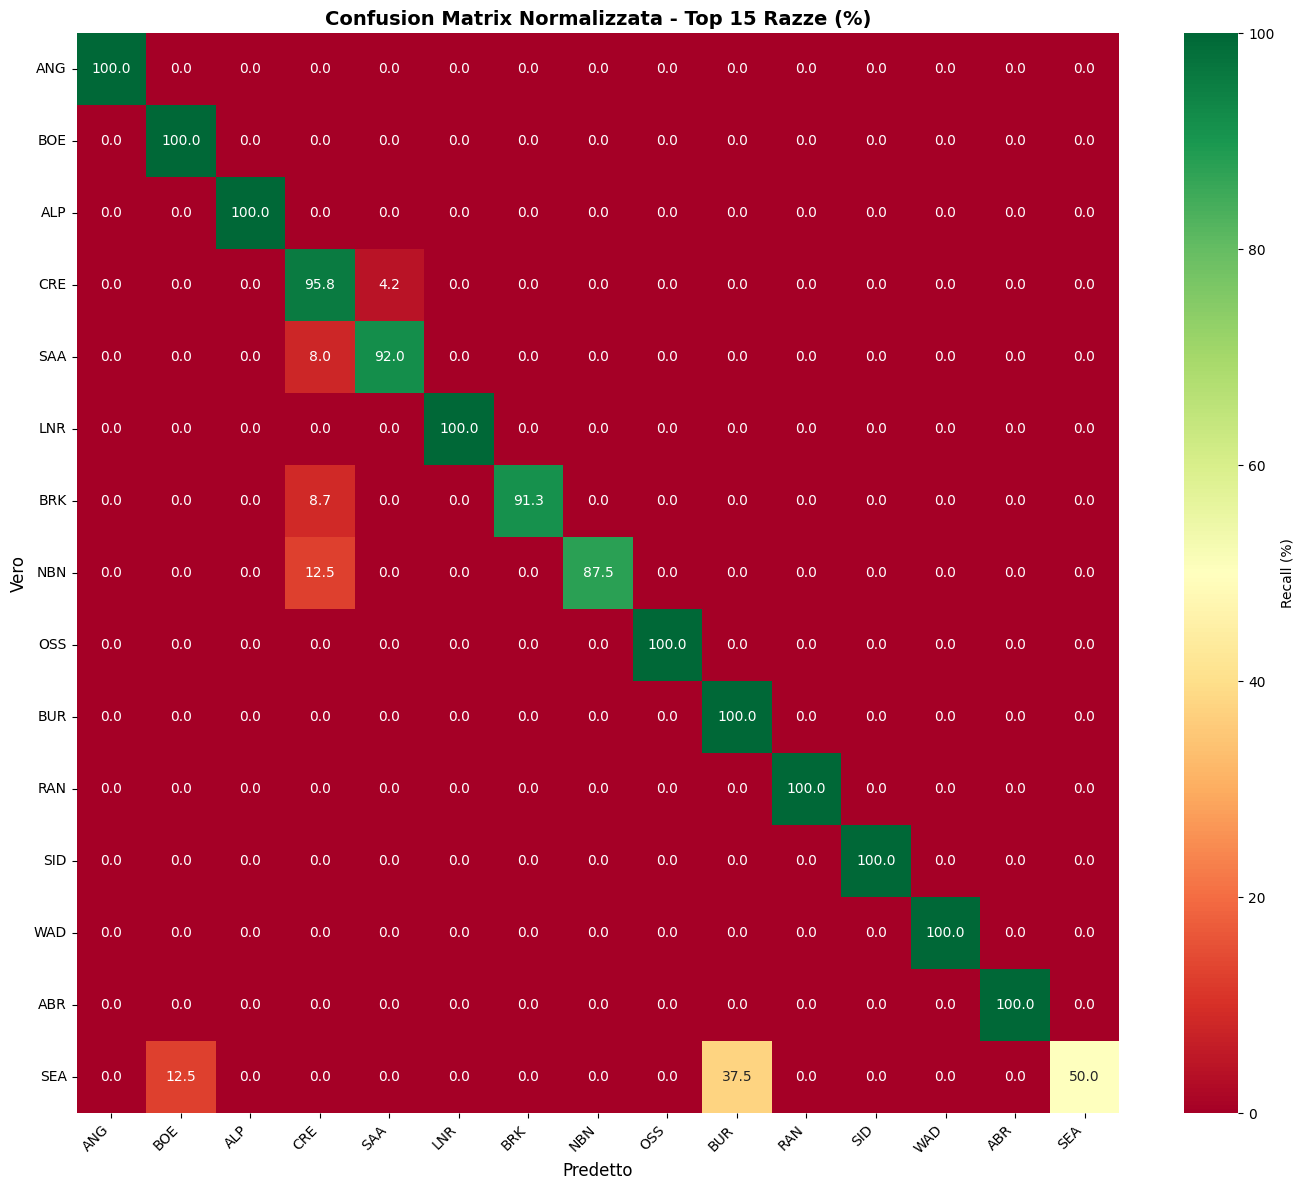


✅ Analisi completata!


In [ ]:
# ============================================================================
# ANALISI PER-CLASSE: Identifica le classi più difficili
# ============================================================================

print("\n📉 CLASSI CON PRESTAZIONI PIÙ BASSE (Bottom 10 per F1-Score)\n")

# Estrai F1-score per classe dal report
report_dict = results['classification_report']
class_f1_scores = []

for class_name in dm.le.classes_:
    if class_name in report_dict:
        f1 = report_dict[class_name]['f1-score']
        support = report_dict[class_name]['support']
        class_f1_scores.append({
            'Razza': class_name,
            'F1-Score': f1,
            'Support': int(support)
        })

df_class_performance = pd.DataFrame(class_f1_scores)
df_class_performance = df_class_performance.sort_values('F1-Score')

print(df_class_performance.head(10).to_string(index=False))

# ============================================================================
# DISTRIBUZIONE CONFIDENZE PREDIZIONI
# ============================================================================

print("\n\n📊 DISTRIBUZIONE CONFIDENZE DELLE PREDIZIONI\n")

# Confidenza massima per ogni predizione
max_probs = np.max(results['y_probs'], axis=1)

# Separa predizioni corrette e sbagliate
correct_mask = results['y_true'] == results['y_pred']
correct_confidences = max_probs[correct_mask]
incorrect_confidences = max_probs[~correct_mask]

print(f"   Confidenza media (predizioni corrette):   {np.mean(correct_confidences):.4f}")
print(f"   Confidenza media (predizioni sbagliate):  {np.mean(incorrect_confidences):.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(correct_confidences, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].set_title('Confidenza - Predizioni CORRETTE', fontsize=12, weight='bold')
axes[0].set_xlabel('Max Probabilità')
axes[0].set_ylabel('Frequenza')
axes[0].axvline(np.mean(correct_confidences), color='darkgreen', linestyle='--', linewidth=2, label=f'Media: {np.mean(correct_confidences):.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(incorrect_confidences, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Confidenza - Predizioni SBAGLIATE', fontsize=12, weight='bold')
axes[1].set_xlabel('Max Probabilità')
axes[1].set_ylabel('Frequenza')
axes[1].axvline(np.mean(incorrect_confidences), color='darkred', linestyle='--', linewidth=2, label=f'Media: {np.mean(incorrect_confidences):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# MATRICE DI CONFUSIONE NORMALIZZATA (%)
# ============================================================================

print("\n\n🔥 CONFUSION MATRIX NORMALIZZATA (per riga - recall per classe)\n")

cm_normalized = results['confusion_matrix'].astype('float') / results['confusion_matrix'].sum(axis=1)[:, np.newaxis]

if dm.num_classes > 20:
    # Mostra solo top 15
    unique, counts = np.unique(results['y_true'], return_counts=True)
    top_classes_idx = np.argsort(counts)[-15:][::-1]
    
    mask = np.isin(results['y_true'], top_classes_idx)
    y_true_filtered = results['y_true'][mask]
    y_pred_filtered = results['y_pred'][mask]
    
    cm_norm_filtered = confusion_matrix(y_true_filtered, y_pred_filtered, labels=top_classes_idx, normalize='true')
    labels_filtered = dm.le.classes_[top_classes_idx]
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm_norm_filtered * 100,  # Converti in percentuale
        annot=True, 
        fmt='.1f', 
        cmap='RdYlGn',
        xticklabels=labels_filtered,
        yticklabels=labels_filtered,
        vmin=0,
        vmax=100,
        cbar_kws={'label': 'Recall (%)'}
    )
    plt.title('Confusion Matrix Normalizzata - Top 15 Razze (%)', fontsize=14, weight='bold')
    plt.ylabel('Vero', fontsize=12)
    plt.xlabel('Predetto', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("\n✅ Analisi completata!")

## 📋 Riassunto Completo dei Risultati

Analisi automatica di tutti i risultati del training e della valutazione:

In [ ]:
def generate_comprehensive_summary(results, datamodule, trainer=None):
    """
    Genera un riassunto completo e leggibile di tutti i risultati
    """
    
    print("\n" + "="*80)
    print("📊 RIASSUNTO COMPLETO DELL'ESPERIMENTO VMGP")
    print("="*80 + "\n")
    
    # ============================================================================
    # 1. INFORMAZIONI DATASET
    # ============================================================================
    print("📂 DATASET\n")
    print(f"   • Nome: AdaptMap Goat Dataset")
    print(f"   • SNP totali (post-QC): {datamodule.num_snps:,}")
    print(f"   • Razze (classi): {datamodule.num_classes}")
    print(f"   • Campioni train: {len(datamodule.train_dataset)}")
    print(f"   • Campioni validation: {len(datamodule.val_dataset)}")
    print(f"   • Campioni test: {len(datamodule.test_dataset)}")
    print(f"   • Totale campioni: {len(datamodule.train_dataset) + len(datamodule.val_dataset) + len(datamodule.test_dataset)}")
    
    # ============================================================================
    # 2. CONFIGURAZIONE MODELLO
    # ============================================================================
    print(f"\n\n🔧 CONFIGURAZIONE MODELLO\n")
    print(f"   • Architettura: VMGP-VAE")
    print(f"   • Input dim: {datamodule.num_snps:,} SNP")
    print(f"   • Latent dim: 32")
    print(f"   • Hidden layers: 2048 → 512 → 32")
    print(f"   • Output classes: {datamodule.num_classes}")
    print(f"   • Learning rate: 0.0001")
    print(f"   • Alpha (reconstruction weight): 0.5")
    
    # ============================================================================
    # 3. TRAINING HISTORY (se disponibile)
    # ============================================================================
    if trainer is not None and hasattr(trainer, 'logged_metrics'):
        print(f"\n\n📈 TRAINING SUMMARY\n")
        try:
            # Prova a leggere le metriche dal logger
            metrics = trainer.logged_metrics
            if 'train_loss' in metrics:
                print(f"   • Final train loss: {metrics['train_loss']:.4f}")
            if 'val_loss' in metrics:
                print(f"   • Final val loss: {metrics['val_loss']:.4f}")
            if 'train_acc' in metrics:
                print(f"   • Final train acc: {metrics['train_acc']*100:.2f}%")
            if 'val_acc' in metrics:
                print(f"   • Final val acc: {metrics['val_acc']*100:.2f}%")
        except:
            print("   ⚠️  Metriche di training non disponibili")
    
    # ============================================================================
    # 4. RISULTATI TEST SET (PRINCIPALI)
    # ============================================================================
    print(f"\n\n🎯 PERFORMANCE SUL TEST SET\n")
    print(f"   ╔═══════════════════════════════════════╗")
    print(f"   ║  METRICA           │      VALORE      ║")
    print(f"   ╠═══════════════════════════════════════╣")
    print(f"   ║  Accuracy          │     {results['accuracy']*100:5.2f}%      ║")
    print(f"   ║  Precision (Macro) │     {results['precision_macro']*100:5.2f}%      ║")
    print(f"   ║  Recall (Macro)    │     {results['recall_macro']*100:5.2f}%      ║")
    print(f"   ║  F1-Score (Macro)  │     {results['f1_macro']*100:5.2f}%      ║")
    print(f"   ╚═══════════════════════════════════════╝")
    
    # ============================================================================
    # 5. ANALISI PER CLASSE
    # ============================================================================
    print(f"\n\n📊 ANALISI PER CLASSE\n")
    
    report = results['classification_report']
    class_scores = []
    
    for class_name in datamodule.le.classes_:
        if class_name in report and isinstance(report[class_name], dict):
            class_scores.append({
                'razza': class_name,
                'f1': report[class_name]['f1-score'],
                'support': report[class_name]['support']
            })
    
    df_scores = pd.DataFrame(class_scores).sort_values('f1', ascending=False)
    
    # Top 5 migliori
    print("   🏆 TOP 5 RAZZE (Migliori F1-Score):\n")
    for i, row in df_scores.head(5).iterrows():
        print(f"      {row['razza']:30s}  F1: {row['f1']:.3f}  (n={int(row['support'])})")
    
    # Bottom 5 peggiori
    print(f"\n   ⚠️  BOTTOM 5 RAZZE (F1-Score più bassi):\n")
    for i, row in df_scores.tail(5).iterrows():
        print(f"      {row['razza']:30s}  F1: {row['f1']:.3f}  (n={int(row['support'])})")
    
    # ============================================================================
    # 6. DISTRIBUZIONE PERFORMANCE
    # ============================================================================
    print(f"\n\n📈 DISTRIBUZIONE PERFORMANCE\n")
    
    f1_scores = df_scores['f1'].values
    print(f"   • Media F1-Score: {np.mean(f1_scores):.3f}")
    print(f"   • Mediana F1-Score: {np.median(f1_scores):.3f}")
    print(f"   • Deviazione standard: {np.std(f1_scores):.3f}")
    print(f"   • Min F1-Score: {np.min(f1_scores):.3f}")
    print(f"   • Max F1-Score: {np.max(f1_scores):.3f}")
    
    # Classi con performance eccellente/buona/media/scarsa
    excellent = (f1_scores >= 0.9).sum()
    good = ((f1_scores >= 0.7) & (f1_scores < 0.9)).sum()
    fair = ((f1_scores >= 0.5) & (f1_scores < 0.7)).sum()
    poor = (f1_scores < 0.5).sum()
    
    print(f"\n   Distribuzione classi per performance:")
    print(f"   • Eccellente (F1 ≥ 0.90): {excellent} razze ({excellent/len(f1_scores)*100:.1f}%)")
    print(f"   • Buona (0.70 ≤ F1 < 0.90): {good} razze ({good/len(f1_scores)*100:.1f}%)")
    print(f"   • Discreta (0.50 ≤ F1 < 0.70): {fair} razze ({fair/len(f1_scores)*100:.1f}%)")
    print(f"   • Scarsa (F1 < 0.50): {poor} razze ({poor/len(f1_scores)*100:.1f}%)")
    
    # ============================================================================
    # 7. ANALISI CONFIDENZE
    # ============================================================================
    print(f"\n\n💯 ANALISI CONFIDENZE PREDIZIONI\n")
    
    max_probs = np.max(results['y_probs'], axis=1)
    correct_mask = results['y_true'] == results['y_pred']
    
    correct_conf = max_probs[correct_mask]
    incorrect_conf = max_probs[~correct_mask]
    
    print(f"   Predizioni CORRETTE:")
    print(f"   • Confidenza media: {np.mean(correct_conf):.4f}")
    print(f"   • Confidenza mediana: {np.median(correct_conf):.4f}")
    
    print(f"\n   Predizioni SBAGLIATE:")
    print(f"   • Confidenza media: {np.mean(incorrect_conf):.4f}")
    print(f"   • Confidenza mediana: {np.median(incorrect_conf):.4f}")
    
    delta_conf = np.mean(correct_conf) - np.mean(incorrect_conf)
    print(f"\n   • Gap confidenza: {delta_conf:.4f}")
    
    if delta_conf > 0.2:
        print(f"   ✅ Il modello è ben calibrato (alta confidenza su predizioni corrette)")
    elif delta_conf > 0.1:
        print(f"   ⚠️  Calibrazione moderata")
    else:
        print(f"   ❌ Calibrazione scarsa (il modello è incerto anche quando sbaglia)")
    
    # ============================================================================
    # 8. SPAZIO LATENTE
    # ============================================================================
    print(f"\n\n🧬 SPAZIO LATENTE\n")
    
    latent_dim = results['latents'].shape[1]
    print(f"   • Dimensione: {latent_dim}")
    print(f"   • Numero campioni: {results['latents'].shape[0]}")
    
    # Calcola varianza spiegata per dimensione
    latent_vars = np.var(results['latents'], axis=0)
    total_var = np.sum(latent_vars)
    
    print(f"   • Varianza totale: {total_var:.2f}")
    print(f"   • Top 5 dimensioni (varianza):")
    top_dims = np.argsort(latent_vars)[-5:][::-1]
    for idx in top_dims:
        print(f"      Dim {idx+1}: {latent_vars[idx]:.3f} ({latent_vars[idx]/total_var*100:.1f}%)")
    
    # ============================================================================
    # 9. RACCOMANDAZIONI
    # ============================================================================
    print(f"\n\n💡 RACCOMANDAZIONI\n")
    
    if results['accuracy'] < 0.5:
        print("   ❌ Accuracy molto bassa. Considera:")
        print("      • Aumentare latent_dim (es. 64 o 128)")
        print("      • Aggiungere layer all'encoder/decoder")
        print("      • Aumentare epoche di training")
        print("      • Verificare qualità dati (SNP informativi)")
    elif results['accuracy'] < 0.7:
        print("   ⚠️  Performance moderate. Possibili miglioramenti:")
        print("      • Feature selection più aggressiva")
        print("      • Data augmentation (se applicabile)")
        print("      • Tuning hyperparameter (alpha, learning rate)")
    else:
        print("   ✅ Performance buone!")
        if poor > 0:
            print(f"   • Ci sono {poor} razze con F1 < 0.5. Considera:")
            print("      • Aumentare campioni per queste razze")
            print("      • Class balancing con weighted loss")
    
    if np.std(f1_scores) > 0.3:
        print("   ⚠️  Alta variabilità tra classi:")
        print("      • Alcune razze sono molto più difficili da classificare")
        print("      • Possibile data imbalance o overlap genetico")
    
    # ============================================================================
    # 10. CONCLUSIONE
    # ============================================================================
    print(f"\n\n{'='*80}")
    print("🎓 CONCLUSIONE")
    print("="*80 + "\n")
    
    if results['accuracy'] >= 0.8 and results['f1_macro'] >= 0.75:
        grade = "OTTIMO"
        emoji = "🏆"
    elif results['accuracy'] >= 0.7 and results['f1_macro'] >= 0.65:
        grade = "BUONO"
        emoji = "✅"
    elif results['accuracy'] >= 0.6 and results['f1_macro'] >= 0.55:
        grade = "DISCRETO"
        emoji = "⚠️"
    else:
        grade = "DA MIGLIORARE"
        emoji = "❌"
    
    print(f"{emoji} Valutazione complessiva: {grade}")
    print(f"\nIl modello VMGP ha raggiunto un'accuracy del {results['accuracy']*100:.2f}% sul test set,")
    print(f"classificando correttamente {int(results['accuracy'] * len(results['y_true']))} su {len(results['y_true'])} campioni.")
    print(f"\nF1-Score macro di {results['f1_macro']:.3f} indica prestazioni {'bilanciate' if results['f1_macro'] > 0.7 else 'sbilanciate'} tra le classi.")
    
    print(f"\n{'='*80}\n")
    
    return df_scores


# ============================================================================
# ESEGUI RIASSUNTO COMPLETO
# ============================================================================

summary_df = generate_comprehensive_summary(results, dm, trainer)

# Salva riassunto in file
summary_df.to_csv("vmgp_class_performance_summary.csv", index=False)
print("📄 Salvato report dettagliato in: vmgp_class_performance_summary.csv")


CAPIRE IL BILANCIAMENTO DEL DATASET
TENERE TRACCIA DI QUANTO VENGA INFLUENZATA LA RICOSTRUZIONE DAL CLASSIFICATORE
LATTE =  ('ALP',  'ARG',  'ASP,  'BIO',  'CRS',  'GGT',  'KLS',	'LNR',  'MLG',	 'MLS',	 'MLT',	 'MUG',	  'NIC',  'ORO',	'PTV',	 'RME',	 'SAA',	 'SAR',	 'TOG',	'VSS',  'NRW’);
FIBRA =  ( 'ANG',  'ANK',	  'CAS' );
CARNE = ( 'BOE',  'RAN',  'TED',  'BRI',   'BEY',  'MOX',  'RAS',  'THA' );

NameError: name 'results' is not defined